In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
from google.colab import files
uploaded=files.upload()

Saving heart_disease_health_indicators_BRFSS2015.csv to heart_disease_health_indicators_BRFSS2015.csv


In [3]:
df=pd.read_csv('/content/heart_disease_health_indicators_BRFSS2015.csv')

In [4]:
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
df.describe()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.094186,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.296921,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.292087,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.698160,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
df.isnull().sum()

,0
HeartDiseaseorAttack,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
Diabetes,0
PhysActivity,0
Fruits,0


In [8]:
cols_to_drop = [
    "CholCheck",
    "AnyHealthcare"
]

df.drop(columns=cols_to_drop, inplace=True)


In [9]:
#1. Overall Health Score
df["Health_Score"] = df["GenHlth"] + df["PhysHlth"] + df["MentHlth"]

# 2. Healthy Lifestyle Score
df["Lifestyle_Score"] = (
    df["PhysActivity"] +
    df["Fruits"] +
    df["Veggies"] -
    df["Smoker"] -
    df["HvyAlcoholConsump"]
)

# 3. Metabolic Risk Score
df["Metabolic_Risk"] = (
    df["HighBP"] +
    df["HighChol"] +
    df["Diabetes"] +
    df["BMI"] / 10
)

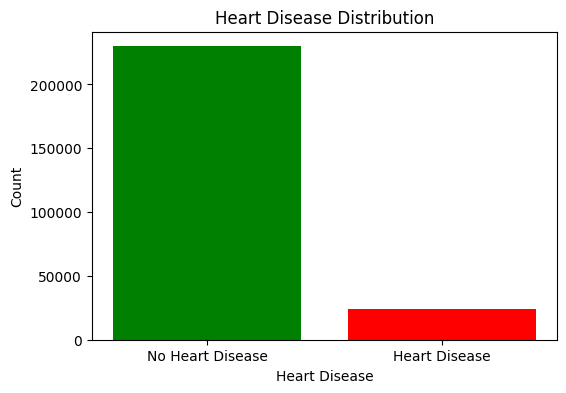

In [10]:
import matplotlib.pyplot as plt

heart = df["HeartDiseaseorAttack"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    heart.values,
    color=["green", "red"]
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

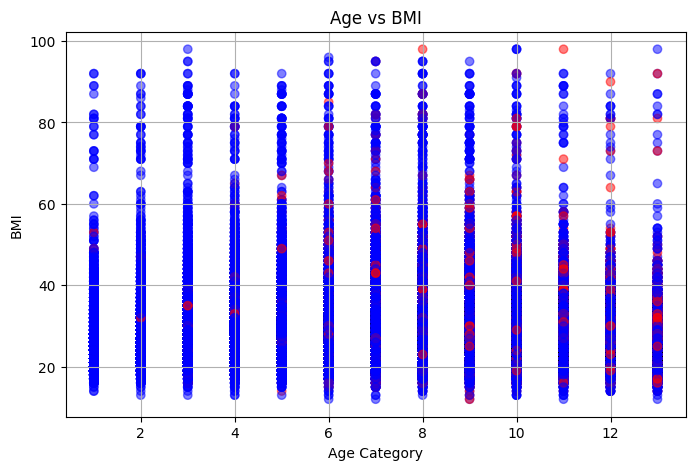

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

colors = ["blue" if x == 0 else "red" for x in df["HeartDiseaseorAttack"]]

plt.scatter(
    df["Age"],
    df["BMI"],
    c=colors,
    alpha=0.5
)

plt.title("Age vs BMI")
plt.xlabel("Age Category")
plt.ylabel("BMI")
plt.grid(True)

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("HeartDiseaseorAttack", axis=1)
y = df["HeartDiseaseorAttack"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9071467991169978
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     45957
         1.0       0.53      0.13      0.20      4779

    accuracy                           0.91     50736
   macro avg       0.72      0.56      0.58     50736
weighted avg       0.88      0.91      0.88     50736

[[45423   534]
 [ 4177   602]]


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.8958530432040366

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94     45957
         1.0       0.37      0.16      0.22      4779

    accuracy                           0.90     50736
   macro avg       0.65      0.56      0.58     50736
weighted avg       0.87      0.90      0.88     50736


Confusion Matrix:
[[44708  1249]
 [ 4035   744]]


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))

AdaBoost Accuracy: 0.9061218858404289

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     45957
         1.0       0.51      0.13      0.21      4779

    accuracy                           0.91     50736
   macro avg       0.71      0.56      0.58     50736
weighted avg       0.88      0.91      0.88     50736


Confusion Matrix:
[[45334   623]
 [ 4140   639]]


In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9074227373068433

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     45957
         1.0       0.54      0.11      0.19      4779

    accuracy                           0.91     50736
   macro avg       0.73      0.55      0.57     50736
weighted avg       0.88      0.91      0.88     50736


Confusion Matrix:
[[45505   452]
 [ 4245   534]]


In [18]:

y_pred = gb.predict(X_test)


print("Predicted Values:")
print(y_pred[:10])


print("Actual Values:")
print(y_test.values[:10])

Predicted Values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Actual Values:
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [19]:
prediction_df = X_test.copy()

prediction_df["Actual"] = y_test.values
prediction_df["Predicted"] = y_pred

prediction_df.head(10)

,HighBP,HighChol,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,...,DiffWalk,Sex,Age,Education,Income,Health_Score,Lifestyle_Score,Metabolic_Risk,Actual,Predicted
198911,1.0,1.0,30.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,11.0,6.0,8.0,2.0,0.0,5.0,0.0,0.0
30665,1.0,1.0,27.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,11.0,6.0,6.0,6.0,1.0,4.7,0.0,0.0
74347,1.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,6.0,6.0,7.0,9.0,1.0,4.1,0.0,0.0
49710,0.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,12.0,6.0,6.0,3.0,0.0,3.6,0.0,0.0
46572,1.0,1.0,25.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,9.0,5.0,7.0,1.0,1.0,4.5,0.0,0.0
57845,0.0,0.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,6.0,7.0,13.0,3.0,2.6,0.0,0.0
192881,1.0,1.0,40.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,11.0,4.0,3.0,32.0,0.0,6.0,1.0,0.0
211406,1.0,0.0,32.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,10.0,4.0,4.0,31.0,1.0,4.2,0.0,0.0
6274,1.0,0.0,31.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,9.0,6.0,8.0,6.0,3.0,5.1,0.0,0.0
125964,0.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,10.0,6.0,8.0,24.0,2.0,3.8,0.0,0.0


In [21]:
# Select the first sample from the test set for prediction
sample_for_prediction = X_test.iloc[[0]]

# Make a prediction using the trained Gradient Boosting model
predicted_disease = gb.predict(sample_for_prediction)

print(f"Sample input features:\n{sample_for_prediction.to_string()}")
print(f"\nPredicted Heart Disease (0: No, 1: Yes): {int(predicted_disease[0])}")

Sample input features:
        HighBP  HighChol   BMI  Smoker  Stroke  Diabetes  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  Income  Health_Score  Lifestyle_Score  Metabolic_Risk
198911     1.0       1.0  30.0     1.0     1.0       0.0           0.0     0.0      1.0                0.0          0.0      2.0       0.0       0.0       0.0  1.0  11.0        6.0     8.0           2.0              0.0             5.0

Predicted Heart Disease (0: No, 1: Yes): 0


In [23]:
import joblib
joblib.dump(gb, 'heart_disease.joblib')

['heart_disease.joblib']